To visualize Variance, we look at how much a model's predictions change when it is trained on different subsets of data. High variance means the model is "overfitting"—it's so flexible that it models the random noise in the training set as if it were a real pattern.

This code simulates "re-training" a model multiple times on different random samples of the same process. You will see that the high-variance model (high-degree polynomial) changes its shape drastically with each new sample.

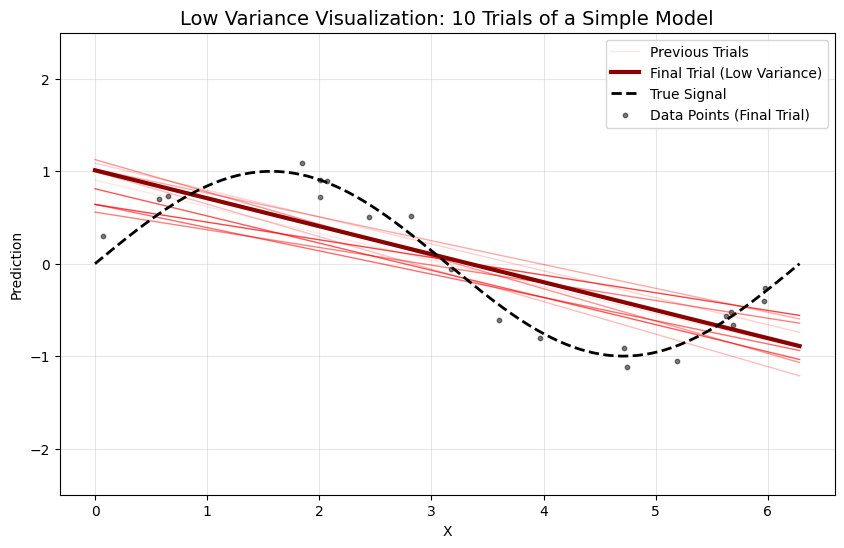

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


# 1. Setup the true signal
def true_func(x):
    return np.sin(x)


np.random.seed(42)
x_plot_low_variance = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
n_trials = 10

plt.figure(figsize=(10, 6))

# 2. Run 10 trials
for i in range(n_trials):
    # Generate new random training data for each trial
    X_train = np.sort(np.random.rand(20, 1) * 2 * np.pi, axis=0)
    y_train = true_func(X_train).ravel() + np.random.normal(0, 0.2, 20)

    # Create a Low Variance model (Simple Linear Regression)
    # A straight line is very rigid and doesn't change much with noise
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Define color and transparency logic
    is_last = i == n_trials - 1
    alpha_val = (
        0.1 + (i * 0.08) if not is_last else 1.0
    )  # Slightly lower increment for 10 trials
    color_val = "red" if not is_last else "darkred"
    linewidth = 1 if not is_last else 3
    label = (
        "Previous Trials"
        if i == 0
        else ("Final Trial (Low Variance)" if is_last else None)
    )

    plt.plot(
        x_plot_low_variance,
        model.predict(x_plot_low_variance),
        color=color_val,
        alpha=alpha_val,
        linewidth=linewidth,
        label=label,
    )

# 3. Plot the ground truth
plt.plot(
    x_plot_low_variance,
    true_func(x_plot_low_variance),
    color="black",
    linestyle="--",
    label="True Signal",
    linewidth=2,
)
plt.scatter(
    X_train, y_train, color="black", s=10, alpha=0.5, label="Data Points (Final Trial)"
)

plt.title(
    f"Low Variance Visualization: {n_trials} Trials of a Simple Model", fontsize=14
)
plt.xlabel("X")
plt.ylabel("Prediction")
plt.ylim(-2.5, 2.5)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

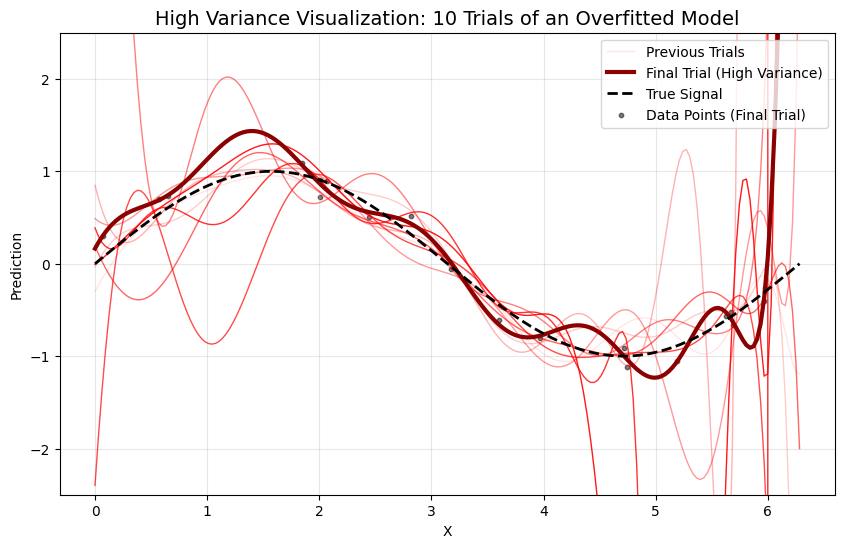

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


# 1. Setup the true signal
def true_func(x):
    return np.sin(x)


np.random.seed(42)
x_plot_high_variance = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
n_trials = 10

plt.figure(figsize=(10, 6))

# 2. Run 10 trials
for i in range(n_trials):
    # Generate new random training data for each trial
    X_train = np.sort(np.random.rand(20, 1) * 2 * np.pi, axis=0)
    y_train = true_func(X_train).ravel() + np.random.normal(0, 0.2, 20)

    # Create a High Variance model (Degree 15)
    model = make_pipeline(PolynomialFeatures(15), LinearRegression())
    model.fit(X_train, y_train)

    # Define color and transparency logic
    # Trial 0 is very light (alpha 0.1), Trial 9 is dark red (alpha 1.0)
    is_last = i == n_trials - 1
    alpha_val = 0.1 + (i * 0.1) if not is_last else 1.0
    color_val = "red" if not is_last else "darkred"
    linewidth = 1 if not is_last else 3
    label = (
        "Previous Trials"
        if i == 0
        else ("Final Trial (High Variance)" if is_last else None)
    )

    plt.plot(
        x_plot_high_variance,
        model.predict(x_plot_high_variance),
        color=color_val,
        alpha=alpha_val,
        linewidth=linewidth,
        label=label,
    )

# 3. Plot the ground truth and clean up
plt.plot(
    x_plot_high_variance,
    true_func(x_plot_high_variance),
    color="black",
    linestyle="--",
    label="True Signal",
    linewidth=2,
)
plt.scatter(
    X_train, y_train, color="black", s=10, alpha=0.5, label="Data Points (Final Trial)"
)

plt.title(
    f"High Variance Visualization: {n_trials} Trials of an Overfitted Model",
    fontsize=14,
)
plt.xlabel("X")
plt.ylabel("Prediction")
plt.ylim(-2.5, 2.5)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

### Comparison of Variance

| Feature | Low Variance | High Variance |
| :--- | :--- | :--- |
| **Consistency** | Very consistent; the lines almost overlap. | Very inconsistent; each trial looks different. |
| **Sensitivity** | Ignores small changes in data. | Extremely sensitive to outliers and noise. |
| **Generalization** | Fails because it's too rigid (High Bias). | Fails because it's "memorizing" specific data. |
| **Complexity** | Low (few parameters). | High (too many parameters/degrees). |

### Summary of the "Tradeoff"
As you increase model complexity (e.g., adding more layers to a neural network or increasing polynomial degrees), **Bias** decreases because the model becomes more capable of representing the truth. However, **Variance** increases because the model gains the freedom to chase noise.

The goal is to find the "sweet spot" where the sum of both is minimized.

1. Regularization (L1/L2)
2. Cross-validation techniques
3. Learning curves visualization

In [3]:
x_plot = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
n_trials = 10

# Containers to store predictions for variance calculation
all_preds_low = []
all_preds_high = []

for i in range(n_trials):
    X_train = np.sort(np.random.rand(20, 1) * 2 * np.pi, axis=0)
    y_train = true_func(X_train).ravel() + np.random.normal(0, 0.2, 20)
    
    # Low Variance Model (Linear)
    model_low = LinearRegression().fit(X_train, y_train)
    all_preds_low.append(model_low.predict(x_plot))
    
    # High Variance Model (Degree 15)
    model_high = make_pipeline(PolynomialFeatures(15), LinearRegression()).fit(X_train, y_train)
    all_preds_high.append(model_high.predict(x_plot))

# Calculate Variance: Mean of (prediction - mean_prediction)^2
var_low = np.mean(np.var(all_preds_low, axis=0))
var_high = np.mean(np.var(all_preds_high, axis=0))

print(f"Average Variance (Linear Model): {var_low:.6f}")
print(f"Average Variance (Degree 15 Model): {var_high:.6f}")
print(f"\nRatio: High Variance model is {var_high/var_low:.1f}x more volatile than Low Variance model.")

Average Variance (Linear Model): 0.038230
Average Variance (Degree 15 Model): 118100573.425663

Ratio: High Variance model is 3089204324.8x more volatile than Low Variance model.
